In [1]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import math
import random

random.seed(42)
def randn():
    u = random.random() or 1e-10
    v = random.random() or 1e-10
    return math.sqrt(-2 * math.log(u)) * math.cos(2 * math.pi * v)

def dot(a, b):
    return sum(x * y for x, y in zip(a, b))

def mean(lst):
    return sum(lst) / len(lst)

def transpose(matrix):
    return [[row[i] for row in matrix] for i in range(len(matrix[0]))]

def sigmoid(z):
    z = max(-500, min(500, z))
    return 1.0 / (1.0 + math.exp(-z))

def softmax(z_list):
    max_z = max(z_list)
    exps  = [math.exp(z - max_z) for z in z_list]
    total = sum(exps)
    return [e / total for e in exps]

print('✅')
print(f'   sigmoid(0)   = {sigmoid(0):.4f}  (expected 0.5)')
print(f'   sigmoid(2)   = {sigmoid(2):.4f}')
print(f'   sigmoid(-2)  = {sigmoid(-2):.4f}')
print(f'   softmax([1,2,3]) = {[round(x,4) for x in softmax([1,2,3])]}')

✅
   sigmoid(0)   = 0.5000  (expected 0.5)
   sigmoid(2)   = 0.8808
   sigmoid(-2)  = 0.1192
   softmax([1,2,3]) = [0.09, 0.2447, 0.6652]


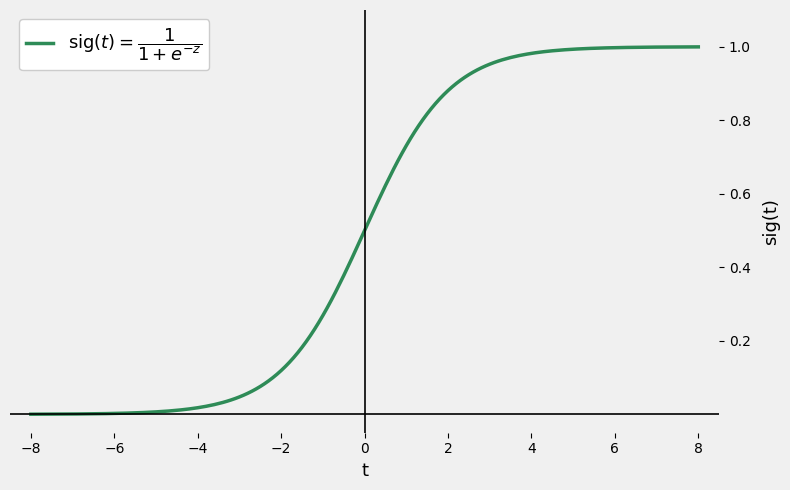

In [3]:
import matplotlib.pyplot as plt
import math
t_vals   = [i * 0.1 for i in range(-80, 81)]
sig_vals = [sigmoid(t) for t in t_vals]

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('#f0f0f0')
ax.set_facecolor('#f0f0f0')

ax.plot(t_vals, sig_vals, color='#2e8b57', linewidth=2.5)


ax.axhline(0, color='black', linewidth=1.2)
ax.axvline(0, color='black', linewidth=1.2)

ax.set_xlim(-8.5, 8.5)
ax.set_ylim(-0.05, 1.1)
ax.set_xlabel('t', fontsize=13)
ax.set_ylabel('sig(t)', fontsize=13, labelpad=8)
ax.yaxis.set_label_position('right')
ax.yaxis.tick_right()

ax.set_xticks(range(-8, 9, 2))
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])

legend_text = r'$\mathrm{sig}(t) = \dfrac{1}{1 + e^{-z}}$'
ax.legend(
    [plt.Line2D([0], [0], color='#2e8b57', linewidth=2.5)],
    [legend_text],
    loc='upper left', fontsize=13,
    framealpha=1, edgecolor='#cccccc',
    facecolor='white', handlelength=1.5
)

ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.grid(False)

plt.tight_layout()
plt.show()

In [4]:
random.seed(42)
N = 200

def make_binary_data(n, seed=42):
    rng = random.Random(seed)
    X, Y = [], []
    for _ in range(n // 2):
        x1 = rng.gauss(-1.0, 0.8)
        x2 = rng.gauss(-1.0, 0.8)
        X.append([x1, x2])
        Y.append(0)
    for _ in range(n // 2):
        x1 = rng.gauss(1.0, 0.8)
        x2 = rng.gauss(1.0, 0.8)
        X.append([x1, x2])
        Y.append(1)
    # Shuffle
    combined = list(zip(X, Y))
    rng.shuffle(combined)
    X, Y = zip(*combined)
    return list(X), list(Y)

X_bin, Y_bin = make_binary_data(N)

print(f'Binary Dataset  :  {N} samples,  2 features,  2 classes')
print(f'Class 0 count   :  {Y_bin.count(0)}')
print(f'Class 1 count   :  {Y_bin.count(1)}')
print(f'X[0]  = {[round(v,4) for v in X_bin[0]]}  →  y = {Y_bin[0]}')
print(f'X[1]  = {[round(v,4) for v in X_bin[1]]}  →  y = {Y_bin[1]}')

Binary Dataset  :  200 samples,  2 features,  2 classes
Class 0 count   :  100
Class 1 count   :  100
X[0]  = [1.5359, 0.0885]  →  y = 1
X[1]  = [-1.8938, -0.6337]  →  y = 0


In [5]:
def binary_forward(x, w, b):
    z = dot(w, x) + b
    return sigmoid(z)
    
n_features = 2
w_bin = [randn() * 0.01 for _ in range(n_features)]
b_bin = 0.0

sample_x = X_bin[0]
prob      = binary_forward(sample_x, w_bin, b_bin)

print(f'Initial weights  →  w = {[round(v,4) for v in w_bin]},  b = {b_bin}')
print()
print(f'Forward pass on X[0]:')
print(f'  x      = {[round(v,4) for v in sample_x]}')
print(f'  z      = w·x + b = {dot(w_bin, sample_x) + b_bin:.4f}')
print(f'  ŷ      = σ(z)    = {prob:.4f}  → P(y=1|x)')
print(f'  pred   = {1 if prob >= 0.5 else 0}  (true label: {Y_bin[0]})')

Initial weights  →  w = [0.0093, 0.0027],  b = 0.0

Forward pass on X[0]:
  x      = [1.5359, 0.0885]
  z      = w·x + b = 0.0146
  ŷ      = σ(z)    = 0.5036  → P(y=1|x)
  pred   = 1  (true label: 1)


In [6]:
def binary_cross_entropy(X, Y, w, b, eps=1e-12):
    total = 0.0
    for x, y in zip(X, Y):
        y_hat = binary_forward(x, w, b)
        y_hat = max(eps, min(1 - eps, y_hat))   # clip for log stability
        total += y * math.log(y_hat) + (1 - y) * math.log(1 - y_hat)
    return -total / len(X)

loss_init = binary_cross_entropy(X_bin, Y_bin, w_bin, b_bin)

print('Binary Cross-Entropy Loss')
print('  L = -(1/N) Σ [ y·log(ŷ) + (1-y)·log(1-ŷ) ]')
print()
print(f'  N        = {N}')
print(f'  w        = {[round(v,4) for v in w_bin]}')
print(f'  b        = {b_bin}')
print(f'  Loss     = {loss_init:.4f}  (untrained, ~log(2) ≈ 0.6931 expected)')

Binary Cross-Entropy Loss
  L = -(1/N) Σ [ y·log(ŷ) + (1-y)·log(1-ŷ) ]

  N        = 200
  w        = [0.0093, 0.0027]
  b        = 0.0
  Loss     = 0.6873  (untrained, ~log(2) ≈ 0.6931 expected)


In [7]:
def binary_gradients(batch_X, batch_Y, w, b):
    n    = len(batch_X)
    n_ft = len(w)
    dw   = [0.0] * n_ft
    db   = 0.0
    for x, y in zip(batch_X, batch_Y):
        y_hat = binary_forward(x, w, b)
        error = y_hat - y
        for j in range(n_ft):
            dw[j] += error * x[j]
        db += error
    return [d / n for d in dw], db / n

dw, db = binary_gradients(X_bin, Y_bin, w_bin, b_bin)

print('Gradient Computation')
print('  ∂L/∂w_j = (1/N) Σ (ŷᵢ - yᵢ) · xᵢⱼ')
print('  ∂L/∂b   = (1/N) Σ (ŷᵢ - yᵢ)')
print()
print(f'  dw = {[round(v,6) for v in dw]}')
print(f'  db = {db:.6f}')

Gradient Computation
  ∂L/∂w_j = (1/N) Σ (ŷᵢ - yᵢ) · xᵢⱼ
  ∂L/∂b   = (1/N) Σ (ŷᵢ - yᵢ)

  dw = [-0.485292, -0.479326]
  db = 0.000246


In [8]:
def sgd_update_vec(w, b, dw, db, lr):
    w_new = [wi - lr * dwi for wi, dwi in zip(w, dw)]
    b_new = b - lr * db
    return w_new, b_new

lr = 0.1
loss_before = binary_cross_entropy(X_bin, Y_bin, w_bin, b_bin)
w_bin, b_bin = sgd_update_vec(w_bin, b_bin, dw, db, lr)
loss_after  = binary_cross_entropy(X_bin, Y_bin, w_bin, b_bin)

print(f'SGD Update  (lr = {lr})')
print(f'  w ← w - η · ∂L/∂w')
print(f'  b ← b - η · ∂L/∂b')
print()
print(f'  Loss before  : {loss_before:.5f}')
print(f'  Loss after   : {loss_after:.5f}')
print(f'  Δ Loss       : {loss_before - loss_after:.5f}  ✓ reduced')

SGD Update  (lr = 0.1)
  w ← w - η · ∂L/∂w
  b ← b - η · ∂L/∂b

  Loss before  : 0.68730
  Loss after   : 0.64221
  Δ Loss       : 0.04509  ✓ reduced


In [9]:
random.seed(42)
w_bin = [randn() * 0.01 for _ in range(n_features)]
b_bin = 0.0

lr         = 0.1
epochs     = 300
batch_size = 16

loss_history_bin = []
acc_history_bin  = []

for epoch in range(1, epochs + 1):
    indices = list(range(len(X_bin)))
    random.shuffle(indices)

    for start in range(0, len(indices), batch_size):
        batch = indices[start : start + batch_size]
        bX    = [X_bin[i] for i in batch]
        bY    = [Y_bin[i] for i in batch]
        dw, db = binary_gradients(bX, bY, w_bin, b_bin)
        w_bin, b_bin = sgd_update_vec(w_bin, b_bin, dw, db, lr)

    loss = binary_cross_entropy(X_bin, Y_bin, w_bin, b_bin)
    preds = [1 if binary_forward(x, w_bin, b_bin) >= 0.5 else 0 for x in X_bin]
    acc   = sum(p == y for p, y in zip(preds, Y_bin)) / len(Y_bin)

    loss_history_bin.append(loss)
    acc_history_bin.append(acc)

    if epoch % 50 == 0 or epoch == 1:
        print(f'Epoch {epoch:4d}  |  loss = {loss:.5f}  |  acc = {acc*100:.2f}%  |  w = {[round(v,4) for v in w_bin]}  b = {b_bin:.4f}')

print(f'\n✅  Binary training done!')
print(f'   Final accuracy  : {acc_history_bin[-1]*100:.2f}%')

Epoch    1  |  loss = 0.36658  |  acc = 97.50%  |  w = [0.4637, 0.4606]  b = -0.0078
Epoch   50  |  loss = 0.09014  |  acc = 97.50%  |  w = [2.4926, 2.4871]  b = -0.0733
Epoch  100  |  loss = 0.08335  |  acc = 97.50%  |  w = [2.9622, 2.9453]  b = -0.0541
Epoch  150  |  loss = 0.08141  |  acc = 97.50%  |  w = [3.2019, 3.1954]  b = -0.0210
Epoch  200  |  loss = 0.08057  |  acc = 97.50%  |  w = [3.3768, 3.3522]  b = -0.0285
Epoch  250  |  loss = 0.08018  |  acc = 97.50%  |  w = [3.4876, 3.4662]  b = -0.0240
Epoch  300  |  loss = 0.07995  |  acc = 97.50%  |  w = [3.5773, 3.5499]  b = 0.0019

✅  Binary training done!
   Final accuracy  : 97.50%


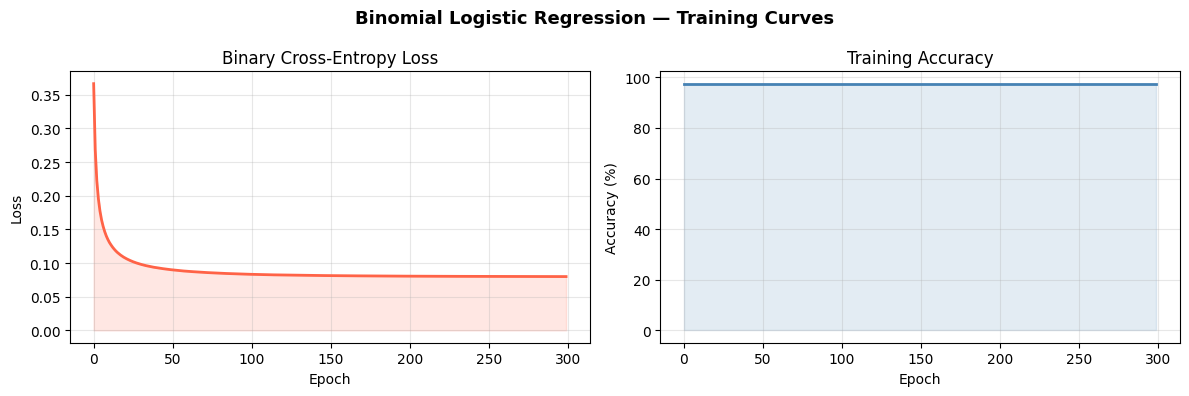

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(loss_history_bin, color='tomato', linewidth=2)
axes[0].fill_between(range(len(loss_history_bin)), loss_history_bin, alpha=0.15, color='tomato')
axes[0].set_title('Binary Cross-Entropy Loss', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(alpha=0.3)

axes[1].plot([a*100 for a in acc_history_bin], color='steelblue', linewidth=2)
axes[1].fill_between(range(len(acc_history_bin)), [a*100 for a in acc_history_bin], alpha=0.15, color='steelblue')
axes[1].set_title('Training Accuracy', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].grid(alpha=0.3)

plt.suptitle('Binomial Logistic Regression — Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

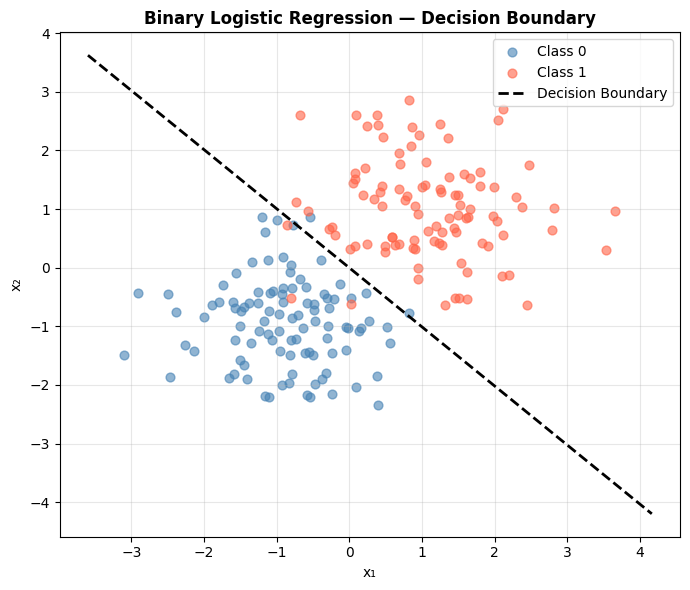

In [11]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 6))

colors = ['steelblue', 'tomato']
for label in [0, 1]:
    pts = [X_bin[i] for i in range(N) if Y_bin[i] == label]
    ax.scatter([p[0] for p in pts], [p[1] for p in pts],
               color=colors[label], alpha=0.6, s=40, label=f'Class {label}')

x1_range = [min(x[0] for x in X_bin) - 0.5, max(x[0] for x in X_bin) + 0.5]
x2_boundary = [-(w_bin[0] * x1 + b_bin) / w_bin[1] for x1 in x1_range]

ax.plot(x1_range, x2_boundary, 'k--', linewidth=2, label='Decision Boundary')
ax.set_xlabel('x₁')
ax.set_ylabel('x₂')
ax.set_title('Binary Logistic Regression — Decision Boundary', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
def make_multiclass_data(n_per_class=80, seed=42):
    rng = random.Random(seed)
    centers = [(-2, 0), (2, 0), (0, 2.5)]
    X, Y = [], []
    for label, (cx, cy) in enumerate(centers):
        for _ in range(n_per_class):
            X.append([rng.gauss(cx, 0.7), rng.gauss(cy, 0.7)])
            Y.append(label)
    combined = list(zip(X, Y))
    rng.shuffle(combined)
    X, Y = zip(*combined)
    return list(X), list(Y)

X_multi, Y_multi = make_multiclass_data(n_per_class=80)
N_multi   = len(X_multi)
n_classes = 3
n_feat    = 2

print(f'Multiclass Dataset  :  {N_multi} samples,  {n_feat} features,  {n_classes} classes')
for c in range(n_classes):
    print(f'  Class {c} count  :  {Y_multi.count(c)}')
print(f'\nX[0] = {[round(v,4) for v in X_multi[0]]}  →  y = {Y_multi[0]}')
print(f'X[1] = {[round(v,4) for v in X_multi[1]]}  →  y = {Y_multi[1]}')

Multiclass Dataset  :  240 samples,  2 features,  3 classes
  Class 0 count  :  80
  Class 1 count  :  80
  Class 2 count  :  80

X[0] = [-1.4621, 0.9953]  →  y = 0
X[1] = [0.6301, -0.0245]  →  y = 1


In [13]:
def multi_forward(x, W, b_vec):
    z = [dot(W[k], x) + b_vec[k] for k in range(len(W))]
    return softmax(z)

random.seed(42)
W_multi = [[randn() * 0.01 for _ in range(n_feat)] for _ in range(n_classes)]
b_multi = [0.0] * n_classes

sample_x   = X_multi[0]
probs      = multi_forward(sample_x, W_multi, b_multi)
pred_class = probs.index(max(probs))

print('Multinomial Forward Pass')
print(f'  x      = {[round(v,4) for v in sample_x]}')
print()
for k in range(n_classes):
    z_k = dot(W_multi[k], sample_x) + b_multi[k]
    print(f'  z_{k}    = W_{k}·x + b_{k} = {z_k:.6f}')
print()
print(f'  softmax(z) = {[round(p,6) for p in probs]}')
print(f'  pred class = {pred_class}  (true label: {Y_multi[0]})')

Multinomial Forward Pass
  x      = [-1.4621, 0.9953]

  z_0    = W_0·x + b_0 = -0.010977
  z_1    = W_1·x + b_1 = 0.009145
  z_2    = W_2·x + b_2 = -0.036218

  softmax(z) = [0.333845, 0.340631, 0.325524]
  pred class = 1  (true label: 0)


In [14]:
def categorical_cross_entropy(X, Y, W, b_vec, eps=1e-12):
    total = 0.0
    for x, y in zip(X, Y):
        probs = multi_forward(x, W, b_vec)
        p_true = max(eps, probs[y])  
        total += math.log(p_true)
    return -total / len(X)

loss_multi_init = categorical_cross_entropy(X_multi, Y_multi, W_multi, b_multi)

print('Categorical Cross-Entropy Loss')
print('  L = -(1/N) Σᵢ Σₖ yᵢₖ · log(ŷᵢₖ)')
print()
print(f'  N       = {N_multi}')
print(f'  Classes = {n_classes}')
print(f'  Loss    = {loss_multi_init:.4f}  (untrained, ~log(3) ≈ 1.0986 expected)')

Categorical Cross-Entropy Loss
  L = -(1/N) Σᵢ Σₖ yᵢₖ · log(ŷᵢₖ)

  N       = 240
  Classes = 3
  Loss    = 1.1185  (untrained, ~log(3) ≈ 1.0986 expected)


In [15]:
def multi_gradients(batch_X, batch_Y, W, b_vec):
    n    = len(batch_X)
    K    = len(W)
    nf   = len(W[0])
    dW   = [[0.0] * nf for _ in range(K)]
    db   = [0.0] * K
    for x, y in zip(batch_X, batch_Y):
        probs = multi_forward(x, W, b_vec)
        for k in range(K):
            y_onehot = 1.0 if y == k else 0.0
            err = probs[k] - y_onehot
            for j in range(nf):
                dW[k][j] += err * x[j]
            db[k] += err
    dW = [[dW[k][j] / n for j in range(nf)] for k in range(K)]
    db = [db[k] / n for k in range(K)]
    return dW, db

def sgd_update_multi(W, b_vec, dW, db, lr):
    W_new = [[W[k][j] - lr * dW[k][j] for j in range(len(W[k]))] for k in range(len(W))]
    b_new = [b_vec[k] - lr * db[k] for k in range(len(b_vec))]
    return W_new, b_new

# 1-step check
dW, db_g = multi_gradients(X_multi, Y_multi, W_multi, b_multi)
loss_bef = categorical_cross_entropy(X_multi, Y_multi, W_multi, b_multi)
W_multi, b_multi = sgd_update_multi(W_multi, b_multi, dW, db_g, lr=0.1)
loss_aft = categorical_cross_entropy(X_multi, Y_multi, W_multi, b_multi)

print('Multinomial Gradient + SGD (1 step)')
print(f'  ∂L/∂W_0 = {[round(v,6) for v in dW[0]]}')
print(f'  ∂L/∂b   = {[round(v,6) for v in db_g]}')
print()
print(f'  Loss before  : {loss_bef:.5f}')
print(f'  Loss after   : {loss_aft:.5f}')
print(f'  Δ Loss       : {loss_bef - loss_aft:.5f}  ✓ reduced')

Multinomial Gradient + SGD (1 step)
  ∂L/∂W_0 = [0.645421, 0.286072]
  ∂L/∂b   = [0.001779, 0.002037, -0.003816]

  Loss before  : 1.11851
  Loss after   : 0.99287
  Δ Loss       : 0.12564  ✓ reduced


In [16]:
random.seed(42)
W_multi = [[randn() * 0.01 for _ in range(n_feat)] for _ in range(n_classes)]
b_multi = [0.0] * n_classes

lr_m         = 0.1
epochs_m     = 400
batch_size_m = 16

loss_history_multi = []
acc_history_multi  = []

for epoch in range(1, epochs_m + 1):
    indices = list(range(N_multi))
    random.shuffle(indices)

    for start in range(0, len(indices), batch_size_m):
        batch  = indices[start : start + batch_size_m]
        bX     = [X_multi[i] for i in batch]
        bY     = [Y_multi[i] for i in batch]
        dW, db_g = multi_gradients(bX, bY, W_multi, b_multi)
        W_multi, b_multi = sgd_update_multi(W_multi, b_multi, dW, db_g, lr_m)

    loss = categorical_cross_entropy(X_multi, Y_multi, W_multi, b_multi)
    preds = [multi_forward(x, W_multi, b_multi).index(max(multi_forward(x, W_multi, b_multi)))
             for x in X_multi]
    acc   = sum(p == y for p, y in zip(preds, Y_multi)) / N_multi

    loss_history_multi.append(loss)
    acc_history_multi.append(acc)

    if epoch % 80 == 0 or epoch == 1:
        print(f'Epoch {epoch:4d}  |  loss = {loss:.5f}  |  acc = {acc*100:.2f}%')

print(f'\n✅  Multinomial training done!')
print(f'   Final accuracy  : {acc_history_multi[-1]*100:.2f}%')

Epoch    1  |  loss = 0.38982  |  acc = 97.50%
Epoch   80  |  loss = 0.05308  |  acc = 98.75%
Epoch  160  |  loss = 0.04809  |  acc = 98.75%
Epoch  240  |  loss = 0.04645  |  acc = 98.75%
Epoch  320  |  loss = 0.04565  |  acc = 98.75%
Epoch  400  |  loss = 0.04518  |  acc = 98.75%

✅  Multinomial training done!
   Final accuracy  : 98.75%


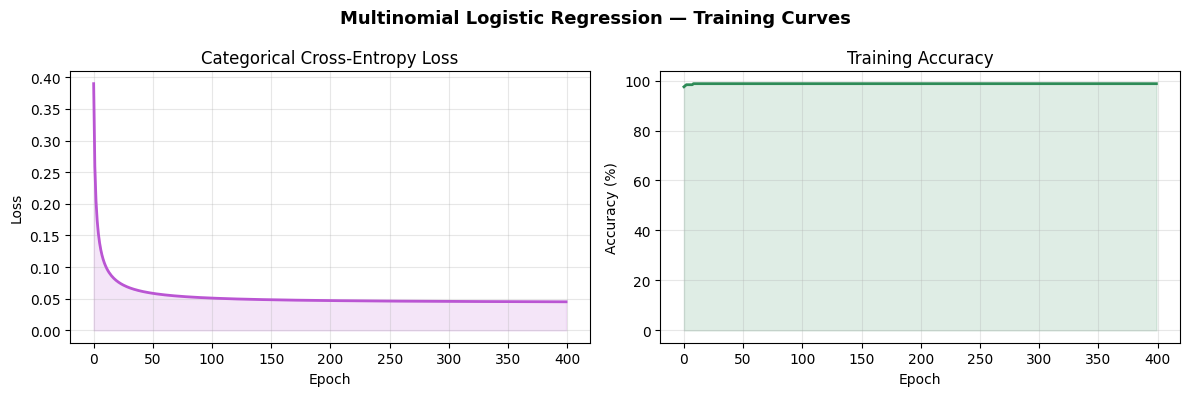

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(loss_history_multi, color='mediumorchid', linewidth=2)
axes[0].fill_between(range(len(loss_history_multi)), loss_history_multi, alpha=0.15, color='mediumorchid')
axes[0].set_title('Categorical Cross-Entropy Loss', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(alpha=0.3)

axes[1].plot([a*100 for a in acc_history_multi], color='seagreen', linewidth=2)
axes[1].fill_between(range(len(acc_history_multi)), [a*100 for a in acc_history_multi], alpha=0.15, color='seagreen')
axes[1].set_title('Training Accuracy', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].grid(alpha=0.3)

plt.suptitle('Multinomial Logistic Regression — Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\Devan\AppData\Local\Temp\ipykernel_13032\527207526.py:33: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\Devan\AppData\Local\Programs\Python\Python310\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


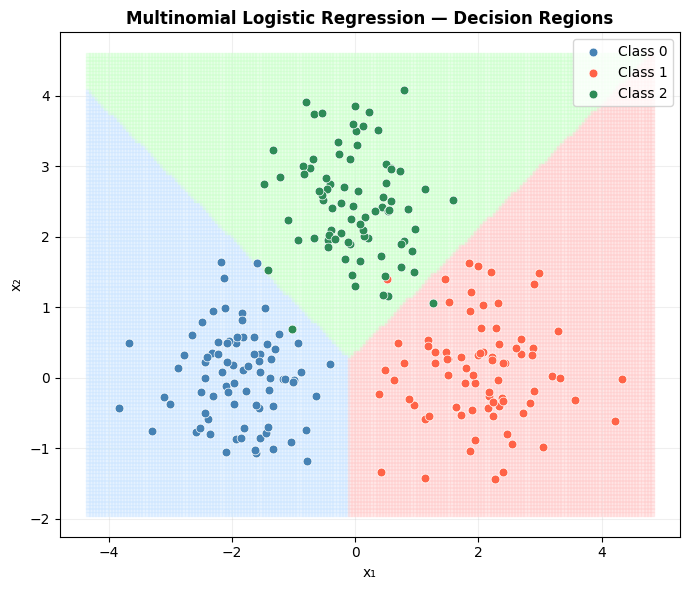

In [18]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 6))

x1_min = min(x[0] for x in X_multi) - 0.5
x1_max = max(x[0] for x in X_multi) + 0.5
x2_min = min(x[1] for x in X_multi) - 0.5
x2_max = max(x[1] for x in X_multi) + 0.5

step = 0.05
xx1 = [x1_min + i * step for i in range(int((x1_max - x1_min) / step) + 1)]
xx2 = [x2_min + i * step for i in range(int((x2_max - x2_min) / step) + 1)]

region_colors = ['#d0e8ff', '#ffd0d0', '#d0ffd0']
point_colors  = ['steelblue', 'tomato', 'seagreen']

for x2v in xx2:
    for x1v in xx1:
        probs  = multi_forward([x1v, x2v], W_multi, b_multi)
        pred_k = probs.index(max(probs))
        ax.plot(x1v, x2v, 's', color=region_colors[pred_k], markersize=3, alpha=0.4)

for label in range(n_classes):
    pts = [X_multi[i] for i in range(N_multi) if Y_multi[i] == label]
    ax.scatter([p[0] for p in pts], [p[1] for p in pts],
               color=point_colors[label], s=40, edgecolors='white',
               linewidths=0.5, label=f'Class {label}', zorder=3)

ax.set_xlabel('x₁')
ax.set_ylabel('x₂')
ax.set_title('Multinomial Logistic Regression — Decision Regions', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [19]:
def confusion_matrix_binary(y_true, y_pred):
    TP = sum(1 for t, p in zip(y_true, y_pred) if t == 1 and p == 1)
    TN = sum(1 for t, p in zip(y_true, y_pred) if t == 0 and p == 0)
    FP = sum(1 for t, p in zip(y_true, y_pred) if t == 0 and p == 1)
    FN = sum(1 for t, p in zip(y_true, y_pred) if t == 1 and p == 0)
    return TP, TN, FP, FN

def f1_score_binary(y_true, y_pred):
    TP, TN, FP, FN = confusion_matrix_binary(y_true, y_pred)
    precision = TP / (TP + FP + 1e-12)
    recall    = TP / (TP + FN + 1e-12)
    f1        = 2 * precision * recall / (precision + recall + 1e-12)
    return precision, recall, f1, TP, TN, FP, FN

# Evaluate binary model
preds_bin = [1 if binary_forward(x, w_bin, b_bin) >= 0.5 else 0 for x in X_bin]
prec, rec, f1, TP, TN, FP, FN = f1_score_binary(Y_bin, preds_bin)

sep = '-' * 44
print('Confusion Matrix (Binary)')
print(sep)
print(f'                 Predicted 0    Predicted 1')
print(f'  Actual 0   :      TN={TN:4d}        FP={FP:4d}')
print(f'  Actual 1   :      FN={FN:4d}        TP={TP:4d}')
print(sep)
print()
print(f'  Precision  = TP / (TP+FP) = {TP} / {TP+FP} = {prec:.4f}')
print(f'  Recall     = TP / (TP+FN) = {TP} / {TP+FN} = {rec:.4f}')
print(f'  F1 Score   = 2·P·R / (P+R)             = {f1:.4f}')
print()
print(f'  Accuracy   = (TP+TN) / N  = {TP+TN} / {N} = {(TP+TN)/N:.4f}')

Confusion Matrix (Binary)
--------------------------------------------
                 Predicted 0    Predicted 1
  Actual 0   :      TN=  98        FP=   2
  Actual 1   :      FN=   3        TP=  97
--------------------------------------------

  Precision  = TP / (TP+FP) = 97 / 99 = 0.9798
  Recall     = TP / (TP+FN) = 97 / 100 = 0.9700
  F1 Score   = 2·P·R / (P+R)             = 0.9749

  Accuracy   = (TP+TN) / N  = 195 / 200 = 0.9750


In [20]:
def f1_score_multiclass(y_true, y_pred, n_cls):
    results = []
    for k in range(n_cls):
        TP = sum(1 for t, p in zip(y_true, y_pred) if t == k and p == k)
        FP = sum(1 for t, p in zip(y_true, y_pred) if t != k and p == k)
        FN = sum(1 for t, p in zip(y_true, y_pred) if t == k and p != k)
        prec = TP / (TP + FP + 1e-12)
        rec  = TP / (TP + FN + 1e-12)
        f1   = 2 * prec * rec / (prec + rec + 1e-12)
        results.append({'class': k, 'TP': TP, 'FP': FP, 'FN': FN,
                        'precision': prec, 'recall': rec, 'f1': f1})
    macro_f1 = sum(r['f1'] for r in results) / n_cls
    return results, macro_f1

preds_multi = [multi_forward(x, W_multi, b_multi).index(max(multi_forward(x, W_multi, b_multi)))
               for x in X_multi]

results_mc, macro_f1 = f1_score_multiclass(Y_multi, preds_multi, n_classes)

sep = '-' * 56
print('Multiclass F1 Score (per-class + macro-average)')
print(sep)
print(f'  {"Class":8}  {"Precision":>10}  {"Recall":>10}  {"F1":>10}')
print(sep)
for r in results_mc:
    print(f'  Class {r["class"]}    {r["precision"]:>10.4f}  {r["recall"]:>10.4f}  {r["f1"]:>10.4f}')
print(sep)
print(f'  Macro F1               {macro_f1:.4f}')
print()
acc_mc = sum(p == y for p, y in zip(preds_multi, Y_multi)) / N_multi
print(f'  Overall Accuracy  :  {acc_mc*100:.2f}%')

Multiclass F1 Score (per-class + macro-average)
--------------------------------------------------------
  Class      Precision      Recall          F1
--------------------------------------------------------
  Class 0        0.9877      1.0000      0.9938
  Class 1        0.9875      0.9875      0.9875
  Class 2        0.9873      0.9750      0.9811
--------------------------------------------------------
  Macro F1               0.9875

  Overall Accuracy  :  98.75%


In [21]:
def roc_curve(y_true, y_scores):
    thresholds = sorted(set(y_scores), reverse=True)
    P = sum(y_true)
    N_neg = len(y_true) - P
    tprs, fprs = [0.0], [0.0]
    for t in thresholds:
        preds_t = [1 if s >= t else 0 for s in y_scores]
        TP = sum(1 for yt, p in zip(y_true, preds_t) if yt == 1 and p == 1)
        FP = sum(1 for yt, p in zip(y_true, preds_t) if yt == 0 and p == 1)
        tprs.append(TP / (P + 1e-12))
        fprs.append(FP / (N_neg + 1e-12))
    tprs.append(1.0); fprs.append(1.0)
    return fprs, tprs

def auc_trapezoidal(x, y):
    """AUC via trapezoidal rule"""
    pairs = sorted(zip(x, y))
    xs, ys = zip(*pairs)
    return sum((xs[i+1] - xs[i]) * (ys[i+1] + ys[i]) / 2
               for i in range(len(xs) - 1))

# Get probability scores for class 1
scores_bin = [binary_forward(x, w_bin, b_bin) for x in X_bin]
fprs, tprs = roc_curve(Y_bin, scores_bin)
auc_roc    = auc_trapezoidal(fprs, tprs)

print('AUC-ROC')
print('  Plots TPR vs FPR across all decision thresholds')
print()
print(f'  AUC-ROC  =  {auc_roc:.4f}')
print()
print(f'  Interpretation:')
print(f'    1.00 = Perfect classifier')
print(f'    0.50 = Random (no skill)')
print(f'    0.00 = Perfectly wrong')
print(f'    → Our model: {"Excellent" if auc_roc >= 0.9 else "Good" if auc_roc >= 0.8 else "Fair"}  ({auc_roc:.4f})')

AUC-ROC
  Plots TPR vs FPR across all decision thresholds

  AUC-ROC  =  0.9952

  Interpretation:
    1.00 = Perfect classifier
    0.50 = Random (no skill)
    0.00 = Perfectly wrong
    → Our model: Excellent  (0.9952)


In [22]:
def pr_curve(y_true, y_scores):
    thresholds = sorted(set(y_scores), reverse=True)
    precisions, recalls = [], []
    for t in thresholds:
        preds_t = [1 if s >= t else 0 for s in y_scores]
        TP = sum(1 for yt, p in zip(y_true, preds_t) if yt == 1 and p == 1)
        FP = sum(1 for yt, p in zip(y_true, preds_t) if yt == 0 and p == 1)
        FN = sum(1 for yt, p in zip(y_true, preds_t) if yt == 1 and p == 0)
        prec = TP / (TP + FP + 1e-12)
        rec  = TP / (TP + FN + 1e-12)
        precisions.append(prec)
        recalls.append(rec)
    # add endpoints
    recalls    = [0.0] + recalls    + [1.0]
    precisions = [1.0] + precisions + [0.0]
    return recalls, precisions

recalls_pr, precisions_pr = pr_curve(Y_bin, scores_bin)
auc_pr = auc_trapezoidal(recalls_pr, precisions_pr)

print('AUC-PR  (Area Under Precision-Recall Curve)')
print('  Plots Precision vs Recall across all decision thresholds')
print()
print(f'  AUC-PR   =  {auc_pr:.4f}')
print()
print(f'  Note: Baseline (random) AUC-PR = class prevalence = {sum(Y_bin)/len(Y_bin):.2f}')
print(f'  → Our model AUC-PR: {auc_pr:.4f}  ({"Excellent" if auc_pr >= 0.9 else "Good" if auc_pr >= 0.8 else "Fair"})')

AUC-PR  (Area Under Precision-Recall Curve)
  Plots Precision vs Recall across all decision thresholds

  AUC-PR   =  0.9949

  Note: Baseline (random) AUC-PR = class prevalence = 0.50
  → Our model AUC-PR: 0.9949  (Excellent)


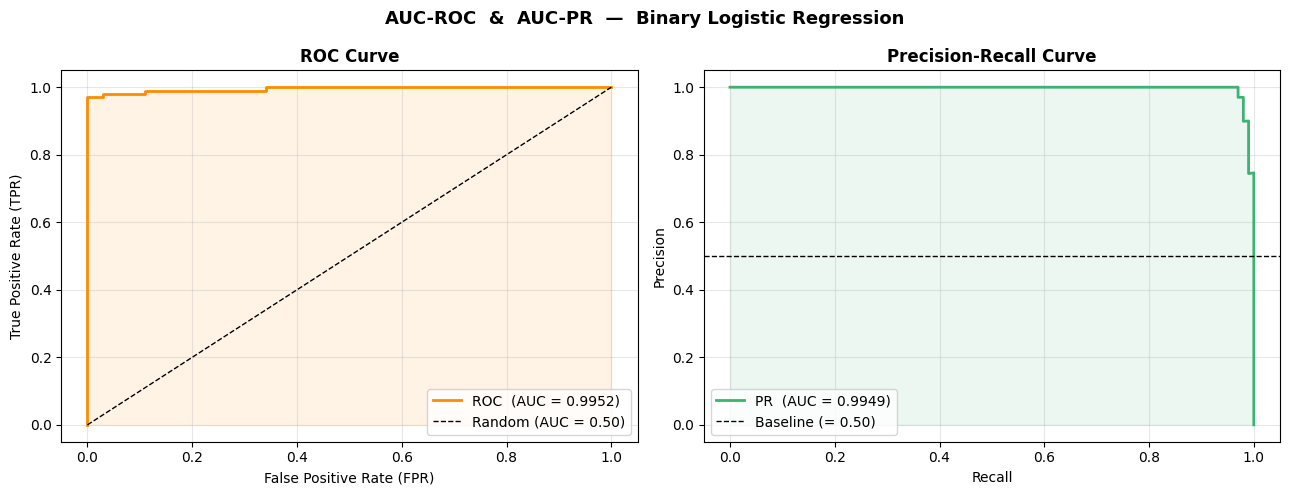

In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── ROC Curve ──
axes[0].plot(fprs, tprs, color='darkorange', linewidth=2, label=f'ROC  (AUC = {auc_roc:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.50)')
axes[0].fill_between(fprs, tprs, alpha=0.1, color='darkorange')
axes[0].set_xlabel('False Positive Rate (FPR)')
axes[0].set_ylabel('True Positive Rate (TPR)')
axes[0].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# ── PR Curve ──
axes[1].plot(recalls_pr, precisions_pr, color='mediumseagreen', linewidth=2, label=f'PR  (AUC = {auc_pr:.4f})')
baseline = sum(Y_bin) / len(Y_bin)
axes[1].axhline(y=baseline, color='k', linestyle='--', linewidth=1, label=f'Baseline (= {baseline:.2f})')
axes[1].fill_between(recalls_pr, precisions_pr, alpha=0.1, color='mediumseagreen')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower left')
axes[1].grid(alpha=0.3)

plt.suptitle('AUC-ROC  &  AUC-PR  —  Binary Logistic Regression', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [24]:
sep = '=' * 58
print(sep)
print('  LOGISTIC REGRESSION — COMPLETE SUMMARY')
print(sep)

print('\n  [ BINOMIAL LOGISTIC REGRESSION ]')
print(f'  Samples         :  {N}')
print(f'  Final Loss      :  {loss_history_bin[-1]:.5f}')
print(f'  Accuracy        :  {acc_history_bin[-1]*100:.2f}%')
print(f'  Precision       :  {prec:.4f}')
print(f'  Recall          :  {rec:.4f}')
print(f'  F1 Score        :  {f1:.4f}')
print(f'  AUC-ROC         :  {auc_roc:.4f}')
print(f'  AUC-PR          :  {auc_pr:.4f}')

print('\n  [ MULTINOMIAL LOGISTIC REGRESSION ]')
print(f'  Samples         :  {N_multi}')
print(f'  Classes         :  {n_classes}')
print(f'  Final Loss      :  {loss_history_multi[-1]:.5f}')
print(f'  Accuracy        :  {acc_history_multi[-1]*100:.2f}%')
print(f'  Macro F1        :  {macro_f1:.4f}')
for r in results_mc:
    print(f'    Class {r["class"]}  F1  :  {r["f1"]:.4f}')

print(f'\n{sep}')

  LOGISTIC REGRESSION — COMPLETE SUMMARY

  [ BINOMIAL LOGISTIC REGRESSION ]
  Samples         :  200
  Final Loss      :  0.07995
  Accuracy        :  97.50%
  Precision       :  0.9798
  Recall          :  0.9700
  F1 Score        :  0.9749
  AUC-ROC         :  0.9952
  AUC-PR          :  0.9949

  [ MULTINOMIAL LOGISTIC REGRESSION ]
  Samples         :  240
  Classes         :  3
  Final Loss      :  0.04518
  Accuracy        :  98.75%
  Macro F1        :  0.9875
    Class 0  F1  :  0.9938
    Class 1  F1  :  0.9875
    Class 2  F1  :  0.9811



                    RESULTS SUMMARY                   
  Metric                      Binary     Multinomial
  ------------------  --------------  --------------
  Final Loss                 0.07995         0.04518
  Accuracy (%)                97.50%          98.75%
  F1 Score                    0.9749          0.9875
  AUC-ROC                     0.9952               —
  AUC-PR                      0.9949               —


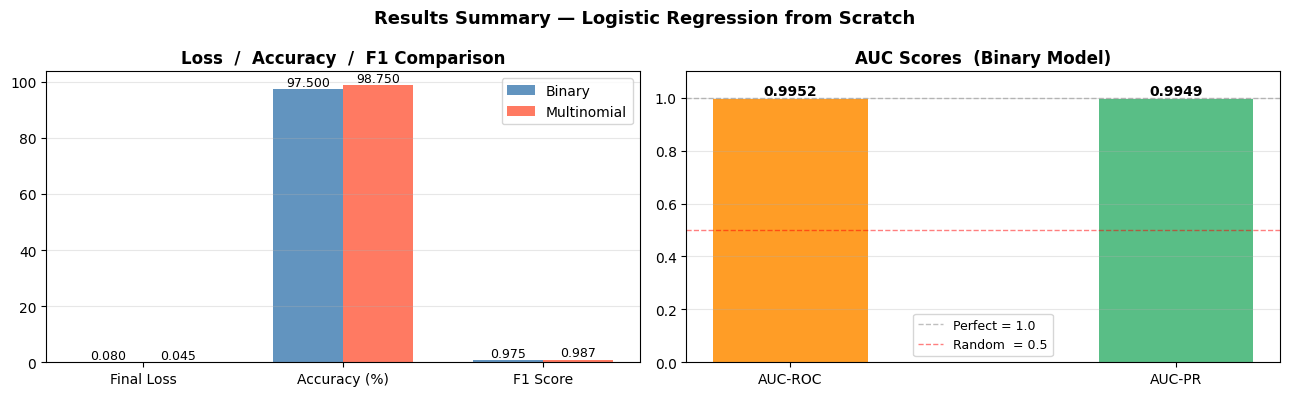

In [28]:
import matplotlib.pyplot as plt

metrics = ['Final Loss', 'Accuracy (%)', 'F1 Score', 'AUC-ROC', 'AUC-PR']

binary_vals = [
    loss_history_bin[-1],
    acc_history_bin[-1] * 100,
    f1,
    auc_roc,
    auc_pr,
]

multi_vals = [
    loss_history_multi[-1],
    acc_history_multi[-1] * 100,
    macro_f1,
    None,
    None,
]

sep = '=' * 56
print(sep)
print(f'  {"RESULTS SUMMARY":^52}')
print(sep)
print(f'  {"Metric":<18}  {"Binary":>14}  {"Multinomial":>14}')
print(f'  {"-"*18}  {"-"*14}  {"-"*14}')

fmt = {
    'Final Loss'   : '{:.5f}',
    'Accuracy (%)' : '{:.2f}%',
    'F1 Score'     : '{:.4f}',
    'AUC-ROC'      : '{:.4f}',
    'AUC-PR'       : '{:.4f}',
}

for metric, bv, mv in zip(metrics, binary_vals, multi_vals):
    f     = fmt[metric]
    b_str = f.format(bv)
    m_str = f.format(mv) if mv is not None else '     —'
    print(f'  {metric:<18}  {b_str:>14}  {m_str:>14}')

print(sep)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

bar_metrics = ['Final Loss', 'Accuracy (%)', 'F1 Score']
bar_binary  = [binary_vals[0], binary_vals[1], binary_vals[2]]
bar_multi   = [multi_vals[0],  multi_vals[1],  multi_vals[2]]

x     = list(range(len(bar_metrics)))
width = 0.35

bars1 = axes[0].bar([xi - width/2 for xi in x], bar_binary,
                    width, label='Binary',      color='steelblue', alpha=0.85)
bars2 = axes[0].bar([xi + width/2 for xi in x], bar_multi,
                    width, label='Multinomial', color='tomato',    alpha=0.85)

for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

axes[0].set_xticks(x)
axes[0].set_xticklabels(bar_metrics)
axes[0].set_title('Loss  /  Accuracy  /  F1 Comparison', fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

auc_labels = ['AUC-ROC', 'AUC-PR']
auc_vals   = [auc_roc, auc_pr]
auc_colors = ['darkorange', 'mediumseagreen']

bars3 = axes[1].bar(auc_labels, auc_vals, color=auc_colors, alpha=0.85, width=0.4)

for bar, val in zip(bars3, auc_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

axes[1].set_ylim(0, 1.1)
axes[1].axhline(y=1.0, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Perfect = 1.0')
axes[1].axhline(y=0.5, color='red',  linestyle='--', linewidth=1, alpha=0.5, label='Random  = 0.5')
axes[1].set_title('AUC Scores  (Binary Model)', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Results Summary — Logistic Regression from Scratch',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()